# 🚨 Accident Triage VLM — Qwen2.5-VL-7B-AWQ
**Module:** Multimodal Context Engine  
**Model:** Qwen2.5-VL-7B-Instruct-AWQ (INT4, ~4.8 GB VRAM)  
**Purpose:** Generate structured triage reports from accident frames  

---

## How this fits in the full pipeline

```
Every frame → EfficientNet-B0 (5ms) → normal: skip
                                     → accident: trigger ↓
Accident frame → YOLOv8n (6ms)      → vehicle bboxes + types
             → Qwen2.5-VL-7B-AWQ   → structured JSON triage report
                    ↓
{alert_level, vehicles, severity, hazards, scene_description, bbox_coords}
```

The VLM only fires **once per accident event** — not per frame.  
Binary alert goes out in <1s. Detailed report follows in 4–6s.

> ⚠️ **GPU Required + High RAM recommended:**  
> Runtime → Change runtime type → T4 GPU + enable High-RAM

In [4]:
# ============================================================
# 1.1  Install dependencies
# ============================================================
# autoawq   — loads AWQ INT4 quantized models
# qwen-vl-utils — Qwen vision preprocessing utilities
# transformers >= 4.45 — required for Qwen2.5-VL
# ============================================================

!pip install -q bitsandbytes
!pip install -q qwen-vl-utils
!pip install -q git+https://github.com/huggingface/transformers accelerate
!pip install -q ultralytics   # YOLOv11 for vehicle detection

print("✅ All dependencies installed")
print("⚠️  Restart runtime now, then skip to cell 1.2")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 35.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ All dependencies installed
⚠️  Restart runtime now, then skip to cell 1.2


In [1]:
# ============================================================
# 1.2  Mount Drive + imports + paths
# ============================================================

from google.colab import drive
import os
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print("✅ Drive already mounted")

import json, time, re, textwrap
from pathlib import Path

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info
from ultralytics import YOLO
import gc
import time
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig

# ── Paths ──────────────────────────────────────────────────
CADP_VIDEOS = Path('/content/drive/MyDrive/Car_accident_detection/Dataset/forth_investigation')
WORK_DIR    = Path('/content/drive/MyDrive/Colab Notebooks/grad-project/program-memory')
DATASET_DIR = WORK_DIR / 'cls_dataset_v2'    # frames from EfficientNet pipeline
RESULTS_DIR = WORK_DIR / 'triage_results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Device ─────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if torch.cuda.is_available():
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"🖥️  GPU: {torch.cuda.get_device_name(0)} ({vram:.1f} GB)")
    print(f"   Free VRAM: {(torch.cuda.mem_get_info()[0]/1e9):.1f} GB")
else:
    print("❌ No GPU — this notebook requires a T4 GPU")

print(f"\n✅ Ready. Results will save to: {RESULTS_DIR}")

✅ Drive already mounted
🖥️  GPU: Tesla T4 (15.6 GB)
   Free VRAM: 15.5 GB

✅ Ready. Results will save to: /content/drive/MyDrive/Colab Notebooks/grad-project/program-memory/triage_results


In [2]:
# ============================================================
# 2.1  Load YOLOv8n vehicle detector
# ============================================================
# Uses the same model already downloaded in the EfficientNet
# pipeline — no extra download needed if cached.
# ============================================================

VEHICLE_CLASSES = {
    0: 'person',
    1: 'bicycle',
    2: 'car',
    3: 'motorcycle',
    5: 'bus',
    7: 'truck'
}
VEHICLE_IDS = set(VEHICLE_CLASSES.keys())

yolo = YOLO('yolov8n.pt')
yolo.to(DEVICE)

print("✅ YOLOv8n loaded")
print(f"   Detecting: {list(VEHICLE_CLASSES.values())}")
print(f"   VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB")

✅ YOLOv8n loaded
   Detecting: ['person', 'bicycle', 'car', 'motorcycle', 'bus', 'truck']
   VRAM used: 0.01 GB


In [3]:
# ============================================================
# 2.2  Load Qwen2.5-VL-7B-Instruct (BitsAndBytes NF4 Quantization)
# ============================================================
# Uses NF4 dynamic quantization to bypass the AWQ ExLlamaV2 crash
# on the 3420 vision dimension. Fits perfectly in Colab T4.
# ============================================================


# SANITY CHECK: Free VRAM if re-running
if 'vlm_model' in globals():
    print("🧹 Cleaning up existing model instance to free VRAM...")
    del vlm_model
    if 'vlm_processor' in globals():
        del vlm_processor
    gc.collect()
    torch.cuda.empty_cache()

# Use the BASE model, not the AWQ version
MODEL_ID = "Qwen/Qwen2.5-VL-7B-Instruct"

print(f"Loading {MODEL_ID} with BitsAndBytes NF4...")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

t0 = time.time()

vlm_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    device_map="auto",
    quantization_config=bnb_config
)

vlm_processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    min_pixels=256 * 28 * 28,
    max_pixels=512 * 28 * 28,
)

elapsed = time.time() - t0
print(f"\n✅ Qwen2.5-VL-7B (NF4) loaded in {elapsed:.0f}s")
print(f"   VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"   VRAM free: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB")

Loading Qwen/Qwen2.5-VL-7B-Instruct with BitsAndBytes NF4...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


✅ Qwen2.5-VL-7B (NF4) loaded in 59s
   VRAM used: 6.26 GB
   VRAM free: 9.17 GB


In [9]:
# ============================================================
# 3.1  Vehicle detection — with accident cluster isolation
# ============================================================
import cv2
import time
import torch
from PIL import Image

VEHICLE_CLASSES = {
    0: 'person', 1: 'bicycle', 2: 'car',
    3: 'motorcycle', 5: 'bus', 7: 'truck'
}
VEHICLE_IDS = set(VEHICLE_CLASSES.keys())
CLUSTER_RADIUS_FRAC = 0.30  # fraction of frame width

def _box_center(bbox):
    return ((bbox[0]+bbox[2])/2, (bbox[1]+bbox[3])/2)

def _box_iou(b1, b2):
    ix1=max(b1[0],b2[0]); iy1=max(b1[1],b2[1])
    ix2=min(b1[2],b2[2]); iy2=min(b1[3],b2[3])
    if ix2<=ix1 or iy2<=iy1: return 0.0
    inter=(ix2-ix1)*(iy2-iy1)
    a1=(b1[2]-b1[0])*(b1[3]-b1[1])
    a2=(b2[2]-b2[0])*(b2[3]-b2[1])
    return inter/(a1+a2-inter+1e-6)

def _center_dist(b1, b2):
    c1,c2=_box_center(b1),_box_center(b2)
    return ((c1[0]-c2[0])**2+(c1[1]-c2[1])**2)**0.5

def find_accident_cluster(detections, frame_w):
    vehicles    = [d for d in detections if d['class'] != 'person']
    pedestrians = [d for d in detections if d['class'] == 'person']

    if len(vehicles) == 0:
        return {'involved_vehicles':[],'all_vehicles':[],'pedestrians_near':[],
                'pedestrians_all':pedestrians,'collision_point':None,
                'max_iou':0.0,'accident_bbox':None}

    if len(vehicles) == 1:
        v=vehicles[0]; cx,cy=_box_center(v['bbox'])
        return {'involved_vehicles':vehicles,'all_vehicles':vehicles,
                'pedestrians_near':[],'pedestrians_all':pedestrians,
                'collision_point':(cx,cy),'max_iou':0.0,'accident_bbox':v['bbox']}

    best_iou=0.0; best_pair=(0,1); best_dist=float('inf'); closest_pair=(0,1)
    for i in range(len(vehicles)):
        for j in range(i+1, len(vehicles)):
            iou  = _box_iou(vehicles[i]['bbox'], vehicles[j]['bbox'])
            dist = _center_dist(vehicles[i]['bbox'], vehicles[j]['bbox'])
            if iou  > best_iou:  best_iou=iou;   best_pair=(i,j)
            if dist < best_dist: best_dist=dist;  closest_pair=(i,j)

    anchor  = best_pair if best_iou > 0.05 else closest_pair
    v_a,v_b = vehicles[anchor[0]], vehicles[anchor[1]]
    ca,cb   = _box_center(v_a['bbox']), _box_center(v_b['bbox'])
    cx,cy   = (ca[0]+cb[0])/2, (ca[1]+cb[1])/2
    radius  = frame_w * CLUSTER_RADIUS_FRAC

    involved = [v for v in vehicles
                if _center_dist(v['bbox'], [cx,cy,cx,cy]) <= radius
                or v is v_a or v is v_b]

    if involved:
        ax1=min(v['bbox'][0] for v in involved); ay1=min(v['bbox'][1] for v in involved)
        ax2=max(v['bbox'][2] for v in involved); ay2=max(v['bbox'][3] for v in involved)
        accident_bbox=[ax1,ay1,ax2,ay2]
    else:
        involved=[v_a,v_b]; accident_bbox=None

    peds_near=[p for p in pedestrians
               if _center_dist(p['bbox'],[cx,cy,cx,cy]) <= radius*1.5]

    return {'involved_vehicles':involved,'all_vehicles':vehicles,
            'pedestrians_near':peds_near,'pedestrians_all':pedestrians,
            'collision_point':(round(cx,1),round(cy,1)),
            'max_iou':round(best_iou,3),'accident_bbox':accident_bbox}

def detect_vehicles(frame_bgr, conf=0.25):
    h,w = frame_bgr.shape[:2]
    results = yolo.predict(frame_bgr, verbose=False, conf=conf,
                           classes=list(VEHICLE_IDS))
    r = results[0]
    detections=[]
    if r.boxes is not None and len(r.boxes)>0:
        for box in r.boxes:
            cls_id=int(box.cls.item())
            if cls_id not in VEHICLE_IDS: continue
            x1,y1,x2,y2=[int(v) for v in box.xyxy[0].tolist()]
            detections.append({'class':VEHICLE_CLASSES[cls_id],
                               'confidence':round(float(box.conf.item()),3),
                               'bbox':[x1,y1,x2,y2]})
    cluster=find_accident_cluster(detections, frame_w=w)
    type_counts={}
    for v in cluster['involved_vehicles']:
        c=v['class']; type_counts[c]=type_counts.get(c,0)+1
    return {'involved_vehicles':cluster['involved_vehicles'],
            'vehicle_types':list(type_counts.keys()),
            'vehicle_count':len(cluster['involved_vehicles']),
            'pedestrian_count':len(cluster.get('pedestrians_near',[])),
            'max_vehicle_overlap':cluster['max_iou'],
            'collision_point':cluster['collision_point'],
            'accident_bbox':cluster['accident_bbox'],
            'all_vehicles_count':len(cluster['all_vehicles']),
            'detections':detections}

print("✅ Vehicle detection with accident cluster isolation ready")


✅ Vehicle detection with accident cluster isolation ready


In [10]:

# ============================================================
# 3.2  VLM triage prompt — grounded, enum hazards, no hallucination
# ============================================================

ALLOWED_HAZARDS = [
    "vehicle_blocking_lane", "debris_on_road", "fluid_spill",
    "smoke_visible", "fire_visible", "pedestrian_near_collision",
    "overturned_vehicle", "airbag_deployed", "broken_glass_visible",
    "traffic_backup",
]

SYSTEM_PROMPT = """You are an AI emergency response assistant analyzing
a traffic camera frame after an accident has been detected.

CRITICAL RULES:
1. Output ONLY valid JSON — no markdown, no code fences, no explanation.
2. Every field must be present. Use null if unknown.
3. HAZARDS: Only use values from this exact list —
   vehicle_blocking_lane | debris_on_road | fluid_spill |
   smoke_visible | fire_visible | pedestrian_near_collision |
   overturned_vehicle | airbag_deployed | broken_glass_visible |
   traffic_backup
   Use empty list [] if none are visually confirmed.
4. DO NOT infer hazards. Only report what you can see.
   Cannot clearly see flames? Do NOT add fire_visible.
   Cannot clearly see smoke? Do NOT add smoke_visible.
5. vehicles_involved: list ONLY vehicles at the collision zone.
   Ignore vehicles clearly far from the accident point.
6. recommended_units: always include police. Add ambulance if severity>=3.
   Add fire ONLY if fire_visible is confirmed in hazards.

JSON schema:
{
  "alert_level": "LOW | MEDIUM | HIGH | CRITICAL",
  "scene_description": "one factual sentence",
  "vehicles_involved": ["car","motorcycle",etc — involved only],
  "vehicle_count": <integer>,
  "pedestrians_in_scene": <true|false>,
  "collision_zone": "location description",
  "road_type": "intersection|highway|urban road|rural road|unknown",
  "hazards": ["from allowed list only"],
  "visibility_conditions": "daytime|nighttime|low light|rain|fog|unknown",
  "severity_score": <1-5>,
  "recommended_units": ["police"] or ["police","ambulance"] etc,
  "confidence": <0.0-1.0>
}

Severity: 1=minor 2=moderate 3=serious 4=major 5=critical"""

def build_user_message(frame_pil, yolo_data):
    inv   = yolo_data.get('involved_vehicles', [])
    total = yolo_data.get('all_vehicles_count', 0)
    cp    = yolo_data.get('collision_point')
    abbox = yolo_data.get('accident_bbox')
    types = ', '.join(v['class'] for v in inv) if inv else 'not detected'
    zone  = (f"pixel [{abbox[0]},{abbox[1]}] to [{abbox[2]},{abbox[3]}]"
             if abbox else f"approx ({cp[0]:.0f},{cp[1]:.0f})" if cp else "unknown")
    context = (
        f"YOLOv8n results:\n"
        f"  Vehicles in accident zone: {len(inv)} ({types})\n"
        f"  Total vehicles in frame  : {total} (ignore distant ones)\n"
        f"  Accident zone location   : {zone}\n"
        f"  Vehicle overlap IoU      : {yolo_data.get('max_vehicle_overlap',0):.3f}"
        f" ({'direct contact' if yolo_data.get('max_vehicle_overlap',0)>0.05 else 'near miss/close'})\n"
        f"  Pedestrians near zone    : {yolo_data.get('pedestrian_count',0)}\n"
        f"\nFocus on the accident zone. Output triage JSON only."
    )
    return [
        # FIXED: Properly inject the SYSTEM_PROMPT into the messages array
        {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
        {"role": "user", "content": [
            {"type": "image", "image": frame_pil},
            {"type": "text", "text": context}
        ]}
    ]

print("✅ Grounded triage prompt ready")


print(f"   Closed hazard enum: {len(ALLOWED_HAZARDS)} allowed values")


✅ Grounded triage prompt ready
   Closed hazard enum: 10 allowed values


In [12]:
# ============================================================
# 3.3  Inference + post-processing validation
# ============================================================
import re as _re, json as _json

def _check_fire_smoke(frame_bgr, accident_bbox):
    """Check if fire/smoke colors actually present in accident zone."""
    if accident_bbox:
        x1,y1,x2,y2 = accident_bbox
        pad=30; h,w=frame_bgr.shape[:2]
        zone=frame_bgr[max(0,y1-pad):min(h,y2+pad),
                       max(0,x1-pad):min(w,x2+pad)]
    else:
        zone=frame_bgr
    if zone.size==0:
        return {'fire_likely':False,'smoke_likely':False}
    hsv = cv2.cvtColor(zone,cv2.COLOR_BGR2HSV).astype(float)
    H,S,V = hsv[:,:,0],hsv[:,:,1],hsv[:,:,2]
    total  = H.size
    fire_r  = float(((( H<20)|(H>160))&(S>120)&(V>80) ).sum()) / total
    smoke_r = float(((S<40)&(V>150)).sum()) / total
    return {'fire_likely':fire_r>0.02,'smoke_likely':smoke_r>0.05,
            'fire_ratio':round(fire_r,4),'smoke_ratio':round(smoke_r,4)}

def validate_report(report, frame_bgr, yolo_data):
    """Remove hallucinated fire/smoke if pixels don't support them."""
    hazards = report.get('hazards', [])
    if not isinstance(hazards, list): hazards=[]
    fire_c  = 'fire_visible'  in hazards
    smoke_c = 'smoke_visible' in hazards
    if fire_c or smoke_c:
        pix = _check_fire_smoke(frame_bgr, yolo_data.get('accident_bbox'))
        report['_pixel_check'] = pix
        removed=[]
        if fire_c  and not pix['fire_likely']:
            hazards=[h for h in hazards if h!='fire_visible'];  removed.append('fire_visible')
        if smoke_c and not pix['smoke_likely']:
            hazards=[h for h in hazards if h!='smoke_visible']; removed.append('smoke_visible')
        if removed:
            report['_removed_hallucinations']=removed
            if 'fire_visible' in removed:
                units=report.get('recommended_units',[])
                if isinstance(units,list):
                    report['recommended_units']=[u for u in units if u!='fire']
    # Clamp to allowed list
    report['hazards']=[h for h in hazards if h in ALLOWED_HAZARDS]
    return report

def _parse_json_robust(text):
    # SAFE FIX: Uses simple string replacement instead of regex backticks!
    clean_text = text.replace("```json", "").replace("```", "").strip()
    try:
        return _json.loads(clean_text)
    except _json.JSONDecodeError:
        m=_re.search(r'\{.*\}',clean_text,_re.DOTALL)
        if m:
            try: return _json.loads(m.group())
            except: pass
    return {'_parse_error':True,'_raw':text}

from qwen_vl_utils import process_vision_info

def generate_triage_report(frame_bgr, max_new_tokens=220, temperature=0.1):
    t_start=time.time()
    t1=time.time(); yolo_data=detect_vehicles(frame_bgr); t_yolo=time.time()-t1
    frame_pil=Image.fromarray(cv2.cvtColor(frame_bgr,cv2.COLOR_BGR2RGB))
    messages=build_user_message(frame_pil, yolo_data)
    text=vlm_processor.apply_chat_template(messages,tokenize=False,add_generation_prompt=True)
    image_inputs,video_inputs=process_vision_info(messages)
    inputs=vlm_processor(text=[text],images=image_inputs,videos=video_inputs,
                         padding=True,return_tensors="pt").to(DEVICE)
    t2=time.time()
    with torch.no_grad():
        output_ids=vlm_model.generate(**inputs,max_new_tokens=max_new_tokens,
                                       temperature=temperature,do_sample=(temperature>0))
    trimmed=[o[len(i):] for i,o in zip(inputs.input_ids,output_ids)]
    raw=vlm_processor.batch_decode(trimmed,skip_special_tokens=True,
                                    clean_up_tokenization_spaces=False)[0].strip()
    t_vlm=time.time()-t2
    report=_parse_json_robust(raw)
    report=validate_report(report,frame_bgr,yolo_data)
    report['_raw_output']=raw
    report['_yolo_data']=yolo_data
    report['_timing']={'yolo_ms':round(t_yolo*1000,1),'vlm_sec':round(t_vlm,2),
                        'total_sec':round(time.time()-t_start,2),
                        'tokens_gen':len(trimmed[0]) if trimmed else 0}
    return report

print("✅ Inference + fire/smoke validation ready (Colab syntax error fixed)")

✅ Inference + fire/smoke validation ready (Colab syntax error fixed)


In [7]:
# ============================================================
# 3.4  Visualization helper
# ============================================================

ALERT_COLORS = {
    'LOW':      '#2ecc71',
    'MEDIUM':   '#f39c12',
    'HIGH':     '#e74c3c',
    'CRITICAL': '#8e44ad',
}

CLASS_COLORS = {
    'car': '#3498db', 'truck': '#e74c3c', 'bus': '#9b59b6',
    'motorcycle': '#f39c12', 'bicycle': '#2ecc71', 'person': '#1abc9c',
}

def visualize_triage(frame_bgr: np.ndarray, report: dict, title: str = ""):
    """Display frame with YOLO boxes and triage report side by side."""
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    h, w = frame_rgb.shape[:2]

    fig = plt.figure(figsize=(18, 8))
    gs  = fig.add_gridspec(1, 2, width_ratios=[1.4, 1])
    ax_img  = fig.add_subplot(gs[0])
    ax_text = fig.add_subplot(gs[1])

    # ── Left: Frame with YOLO boxes ─────────────────────────
    ax_img.imshow(frame_rgb)
    yolo_data = report.get('_yolo_data', {})
    for det in yolo_data.get('detections', []):
        x1, y1, x2, y2 = det['bbox']
        color = CLASS_COLORS.get(det['class'], '#ffffff')
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax_img.add_patch(rect)
        ax_img.text(
            x1, y1-6,
            f"{det['class']} {det['confidence']:.0%}",
            color='white', fontsize=8,
            bbox=dict(facecolor=color, alpha=0.8, pad=2, edgecolor='none')
        )

    alert = report.get('alert_level', 'UNKNOWN')
    alert_color = ALERT_COLORS.get(alert, '#888888')
    ax_img.set_title(
        f"⚠ ALERT: {alert}  |  Severity: {report.get('severity_score', '?')}/5",
        fontsize=13, color=alert_color, fontweight='bold', pad=10
    )
    ax_img.axis('off')

    # ── Right: Triage report ────────────────────────────────
    ax_text.axis('off')
    lines = []

    def add(label, value, indent=0):
        prefix = "  " * indent
        if value is None:
            lines.append(f"{prefix}{label}: —")
        elif isinstance(value, list):
            if value:
                lines.append(f"{prefix}{label}:")
                for v in value:
                    lines.append(f"{prefix}  • {v}")
            else:
                lines.append(f"{prefix}{label}: none")
        else:
            lines.append(f"{prefix}{label}: {value}")

    lines.append("─" * 38)
    lines.append(" TRIAGE REPORT")
    lines.append("─" * 38)
    add("Scene",     report.get('scene_description'))
    lines.append("")
    add("Road type",     report.get('road_type'))
    add("Collision zone",report.get('collision_zone'))
    add("Visibility",    report.get('visibility_conditions'))
    lines.append("")
    add("Vehicles",      report.get('vehicles_involved'))
    add("Pedestrians",   report.get('pedestrians_in_scene'))
    lines.append("")
    add("Hazards",       report.get('hazards'))
    lines.append("")
    add("Units needed",  report.get('recommended_units'))
    lines.append("")

    timing = report.get('_timing', {})
    lines.append("─" * 38)
    lines.append(f" YOLO:  {timing.get('yolo_ms', '?')} ms")
    lines.append(f" VLM:   {timing.get('vlm_sec', '?')} sec")
    lines.append(f" Total: {timing.get('total_sec', '?')} sec")
    lines.append(f" Confidence: {report.get('confidence', '?')}")
    lines.append("─" * 38)

    text = "\n".join(lines)
    ax_text.text(
        0.02, 0.98, text,
        transform=ax_text.transAxes,
        verticalalignment='top',
        fontfamily='monospace',
        fontsize=9.5,
        color='#1a1a2e',
        bbox=dict(boxstyle='round,pad=0.8', facecolor=f'{alert_color}22',
                  edgecolor=alert_color, linewidth=1.5)
    )

    if title:
        fig.suptitle(title, fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()
    return fig

print("✅ Visualization helper ready")

✅ Visualization helper ready


In [13]:
# ============================================================
# 4.1  Test on accident frames from dataset
# ============================================================
# Loads sample accident frames already extracted by the
# EfficientNet pipeline and runs the full triage pipeline.
# ============================================================

acc_dir = DATASET_DIR / 'test' / 'accident'
if not acc_dir.exists():
    print(f"❌ Accident frames not found at {acc_dir}")
    print("   Run the EfficientNet notebook first to build the dataset.")
else:
    import random
    sample_paths = random.sample(
        list(acc_dir.glob('*.jpg')),
        min(3, len(list(acc_dir.glob('*.jpg'))))
    )

    print(f"Testing on {len(sample_paths)} accident frames from dataset\n")

    reports = []
    for i, img_path in enumerate(sample_paths):
        print(f"── Frame {i+1}/{len(sample_paths)}: {img_path.name} ──")

        frame_bgr = cv2.imread(str(img_path))
        if frame_bgr is None:
            print("  ❌ Could not read frame, skipping")
            continue

        report = generate_triage_report(frame_bgr)
        reports.append({'path': str(img_path), 'report': report})

        # Print timing
        t = report['_timing']
        print(f"  ✅ Done — YOLO: {t['yolo_ms']}ms | VLM: {t['vlm_sec']}s | Total: {t['total_sec']}s")
        print(f"  Alert: {report.get('alert_level','?')} | Severity: {report.get('severity_score','?')}/5")
        print(f"  Scene: {report.get('scene_description','?')[:80]}")
        print()

        visualize_triage(frame_bgr, report, title=img_path.name)

    # Save results
    out_file = RESULTS_DIR / 'dataset_test_reports.json'
    with open(out_file, 'w') as f:
        # Remove numpy arrays before saving
        clean = []
        for r in reports:
            rc = dict(r)
            rc['report'] = {k: v for k, v in r['report'].items()
                           if not k.startswith('_yolo') and k != '_raw_output'}
            clean.append(rc)
        json.dump(clean, f, indent=2)
    print(f"💾 Reports saved to {out_file}")

Output hidden; open in https://colab.research.google.com to view.

🎬 -GpvLzopst8.mp4: 1830 frames @ 30fps
  Peak motion: 0.772 at t=34.0s
  Running triage pipeline...
  ✅ YOLO: 18.5ms | VLM: 11.79s | Total: 11.83s


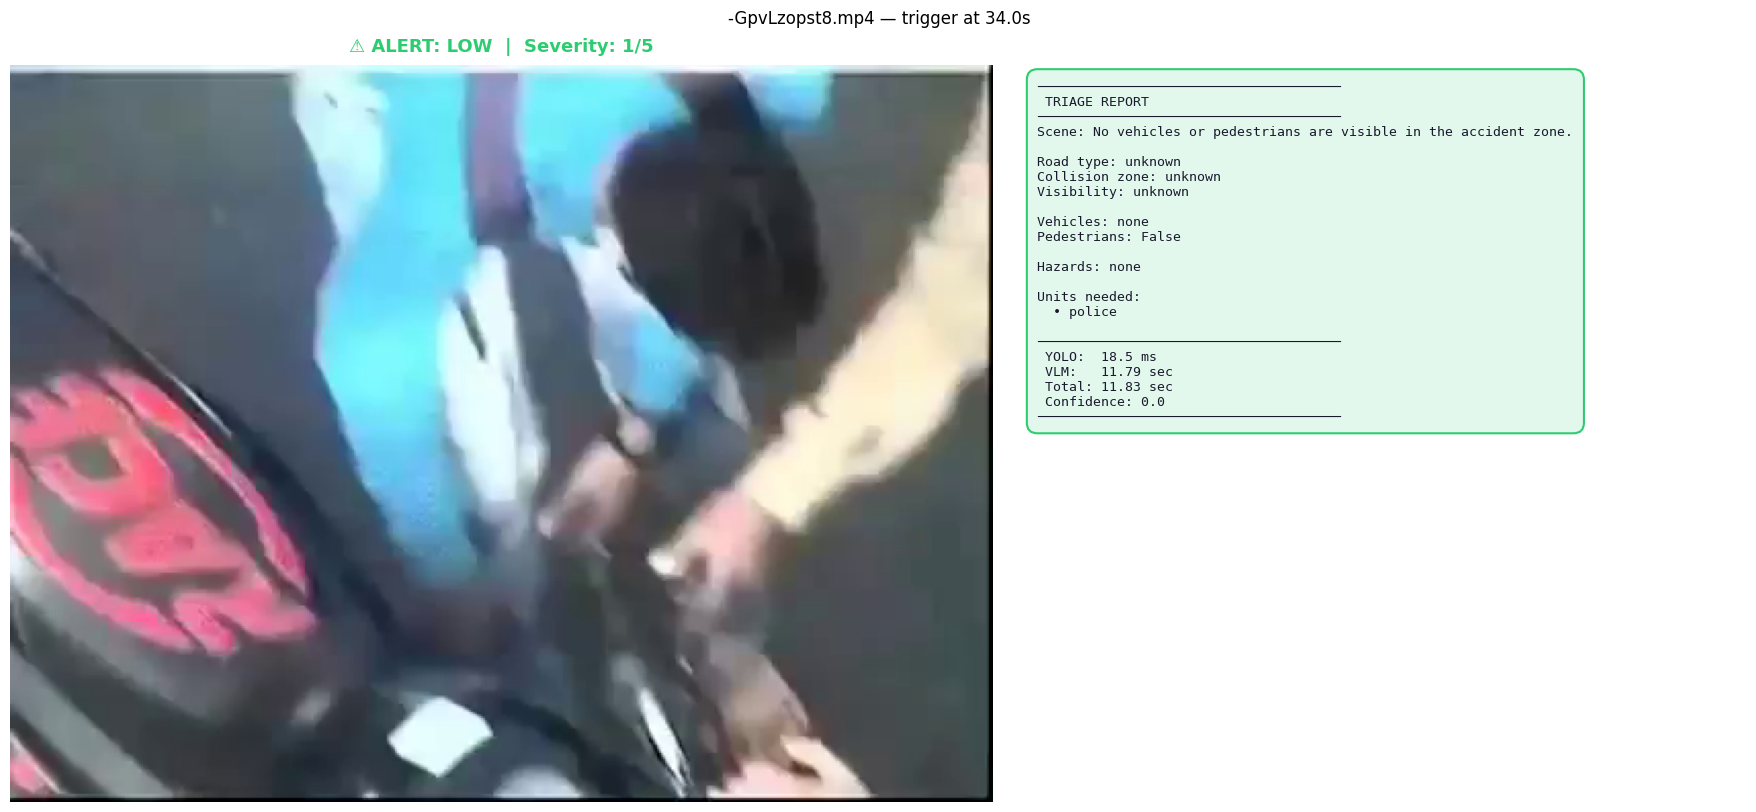


💾 Report saved to /content/drive/MyDrive/Colab Notebooks/grad-project/program-memory/triage_results/video_triage_-GpvLzopst8.json


In [14]:
# ============================================================
# 4.2  Test on a real video — detect accident, trigger triage
# ============================================================
# Simulates the full cascade:
# 1. Slide through video frames
# 2. Detect motion threshold (proxy for EfficientNet)
# 3. On first candidate frame, run full triage pipeline
# ============================================================

def run_triage_on_video(
    video_path:    str,
    sample_every:  int   = 30,   # check every N frames (~1s at 30fps)
    motion_thresh: float = 0.15, # pixel change fraction to flag candidate
    max_sec:       int   = 120,
) -> dict | None:
    """
    Simple demo: uses frame-difference motion detection as a trigger.
    In the full system, EfficientNet replaces this trigger.
    Runs triage only on the first high-motion frame found.
    """
    video_path = Path(video_path)
    cap   = cv2.VideoCapture(str(video_path))
    fps   = cap.get(cv2.CAP_PROP_FPS) or 30
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    limit = min(total, int(max_sec * fps))

    print(f"🎬 {video_path.name}: {total} frames @ {fps:.0f}fps")

    prev_gray = None
    best_frame = None
    best_score = 0.0

    for i in range(limit):
        ret, frame = cap.read()
        if not ret:
            break
        if i % sample_every != 0:
            continue

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.GaussianBlur(gray, (21, 21), 0)

        if prev_gray is not None:
            diff  = cv2.absdiff(prev_gray, gray)
            score = float(np.count_nonzero(diff > 25)) / diff.size
            if score > best_score:
                best_score  = score
                best_frame  = frame.copy()
                best_sec    = i / fps

        prev_gray = gray

    cap.release()

    if best_frame is None:
        print("  No candidate frame found")
        return None

    print(f"  Peak motion: {best_score:.3f} at t={best_sec:.1f}s")
    print(f"  Running triage pipeline...")

    report = generate_triage_report(best_frame)
    report['_source_video'] = video_path.name
    report['_trigger_time_sec'] = round(best_sec, 2)

    t = report['_timing']
    print(f"  ✅ YOLO: {t['yolo_ms']}ms | VLM: {t['vlm_sec']}s | Total: {t['total_sec']}s")

    visualize_triage(
        best_frame, report,
        title=f"{video_path.name} — trigger at {best_sec:.1f}s"
    )

    return report


# ── Run on first video ─────────────────────────────────────
test_vids = sorted(CADP_VIDEOS.glob('*.mp4')) if CADP_VIDEOS.exists() else []

if test_vids:
    video_report = run_triage_on_video(test_vids[0])

    if video_report:
        # Save
        out_file = RESULTS_DIR / f"video_triage_{test_vids[0].stem}.json"
        save_data = {k: v for k, v in video_report.items()
                    if not k.startswith('_yolo') and k != '_raw_output'}
        with open(out_file, 'w') as f:
            json.dump(save_data, f, indent=2)
        print(f"\n💾 Report saved to {out_file}")
else:
    print("❌ No videos found in forth_investigation/")
    print("   You can still test with dataset frames in cell 4.1")

In [15]:
# ============================================================
# 4.3  Batch evaluation on multiple accident frames
#      Quality metrics: JSON validity, field completeness,
#      severity distribution, timing statistics
# ============================================================

from collections import Counter

acc_dir  = DATASET_DIR / 'test' / 'accident'
norm_dir = DATASET_DIR / 'test' / 'no_accident'

if not acc_dir.exists():
    print("❌ Run cell 4.1 first to verify the dataset path")
else:
    N_ACC  = 8   # accident frames to test
    N_NORM = 4   # normal frames — should get low severity / no alert

    acc_frames  = random.sample(list(acc_dir.glob('*.jpg')),
                                min(N_ACC, len(list(acc_dir.glob('*.jpg')))))
    norm_frames = random.sample(list(norm_dir.glob('*.jpg')),
                                min(N_NORM, len(list(norm_dir.glob('*.jpg')))))

    all_frames = [(p, 'accident') for p in acc_frames] +                  [(p, 'normal')   for p in norm_frames]

    results = []
    print(f"Running triage on {len(all_frames)} frames ({N_ACC} accident, {N_NORM} normal)\n")

    for i, (path, gt_label) in enumerate(all_frames):
        frame_bgr = cv2.imread(str(path))
        if frame_bgr is None:
            continue

        report = generate_triage_report(frame_bgr)
        t = report['_timing']

        severity = report.get('severity_score', 0)
        alert    = report.get('alert_level', 'UNKNOWN')
        valid_json = '_parse_error' not in report

        results.append({
            'gt': gt_label, 'severity': severity,
            'alert': alert, 'valid_json': valid_json,
            'vlm_sec': t['vlm_sec'], 'total_sec': t['total_sec'],
        })

        icon = '🚨' if gt_label == 'accident' else '🟢'
        print(f"{icon} [{i+1:2d}/{len(all_frames)}] {gt_label:8s} | "
              f"alert={alert:8s} sev={severity} | "
              f"t={t['total_sec']}s | json={'✅' if valid_json else '❌'}")

    # ── Summary stats ─────────────────────────────────────
    print("\n" + "="*60)
    print("📊 BATCH EVALUATION SUMMARY")
    print("="*60)

    acc_res  = [r for r in results if r['gt'] == 'accident']
    norm_res = [r for r in results if r['gt'] == 'normal']

    print(f"\nAccident frames ({len(acc_res)}):")
    print(f"  Avg severity : {sum(r['severity'] for r in acc_res)/max(len(acc_res),1):.1f}/5")
    print(f"  Alert dist   : {dict(Counter(r['alert'] for r in acc_res))}")
    print(f"  HIGH+CRITICAL: {sum(1 for r in acc_res if r['alert'] in ('HIGH','CRITICAL'))}/{len(acc_res)}")

    print(f"\nNormal frames ({len(norm_res)}):")
    print(f"  Avg severity : {sum(r['severity'] for r in norm_res)/max(len(norm_res),1):.1f}/5")
    print(f"  Alert dist   : {dict(Counter(r['alert'] for r in norm_res))}")

    all_times = [r['vlm_sec'] for r in results]
    print(f"\nTiming (VLM only):")
    print(f"  Min: {min(all_times):.2f}s | Max: {max(all_times):.2f}s | "
          f"Avg: {sum(all_times)/len(all_times):.2f}s")
    print(f"  Successful JSON: {sum(r['valid_json'] for r in results)}/{len(results)}")
    print("="*60)

    # Save batch results
    out_file = RESULTS_DIR / 'batch_evaluation.json'
    with open(out_file, 'w') as f:
        json.dump(results, f, indent=2)
    print(f"\n💾 Batch results saved to {out_file}")

Running triage on 12 frames (8 accident, 4 normal)

🚨 [ 1/12] accident | alert=HIGH     sev=3 | t=14.51s | json=✅
🚨 [ 2/12] accident | alert=MEDIUM   sev=3 | t=13.05s | json=✅
🚨 [ 3/12] accident | alert=MEDIUM   sev=2 | t=13.38s | json=✅
🚨 [ 4/12] accident | alert=HIGH     sev=3 | t=12.29s | json=✅
🚨 [ 5/12] accident | alert=MEDIUM   sev=3 | t=12.9s | json=✅
🚨 [ 6/12] accident | alert=MEDIUM   sev=3 | t=13.69s | json=✅
🚨 [ 7/12] accident | alert=MEDIUM   sev=3 | t=13.59s | json=✅
🚨 [ 8/12] accident | alert=HIGH     sev=3 | t=13.37s | json=✅
🟢 [ 9/12] normal   | alert=LOW      sev=1 | t=11.13s | json=✅
🟢 [10/12] normal   | alert=MEDIUM   sev=3 | t=13.11s | json=✅
🟢 [11/12] normal   | alert=MEDIUM   sev=1 | t=13.34s | json=✅
🟢 [12/12] normal   | alert=MEDIUM   sev=3 | t=13.82s | json=✅

📊 BATCH EVALUATION SUMMARY

Accident frames (8):
  Avg severity : 2.9/5
  Alert dist   : {'HIGH': 3, 'MEDIUM': 5}
  HIGH+CRITICAL: 3/8

Normal frames (4):
  Avg severity : 2.0/5
  Alert dist   : {'LOW': 1

In [16]:
# ============================================================
# 4.4  Print a formatted sample triage report
#      (shows exactly what a dispatcher would receive)
# ============================================================

def print_dispatcher_alert(report: dict, video_name: str = "CAM-01"):
    """Format a triage report as a dispatcher-style alert."""
    alert   = report.get('alert_level', 'UNKNOWN')
    sev     = report.get('severity_score', '?')
    color   = {'LOW': '\033[92m', 'MEDIUM': '\033[93m',
                'HIGH': '\033[91m', 'CRITICAL': '\033[95m'}.get(alert, '')
    reset   = '\033[0m'

    units = ', '.join(report.get('recommended_units', [])) or 'TBD'
    vehs  = ', '.join(report.get('vehicles_involved', [])) or 'unknown'
    haz   = ', '.join(report.get('hazards', [])) or 'none reported'

    print(f"{color}{'='*55}")
    print(f"  ⚠  ACCIDENT ALERT — {alert}  (Severity {sev}/5)")
    print(f"{'='*55}{reset}")
    print(f"  Camera    : {video_name}")
    print(f"  Time      : {time.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"  Road type : {report.get('road_type', 'unknown')}")
    print(f"  Zone      : {report.get('collision_zone', 'unknown')}")
    print()
    print(f"  Scene: {report.get('scene_description', 'N/A')}")
    print()
    print(f"  Vehicles  : {vehs}  ({report.get('vehicle_count', '?')} total)")
    print(f"  Pedestrians detected: {report.get('pedestrians_in_scene', '?')}")
    print(f"  Hazards   : {haz}")
    print(f"  Visibility: {report.get('visibility_conditions', 'unknown')}")
    print()
    print(f"  ➤  Dispatch: {units}")
    t = report.get('_timing', {})
    print(f"  ➤  AI confidence: {report.get('confidence', '?')}")
    print(f"  ➤  Detection time: {t.get('total_sec', '?')}s")
    print(f"{'='*55}")

# ── Test with the most recent report ──────────────────────
report_files = sorted(RESULTS_DIR.glob('*.json'))
if report_files:
    with open(report_files[-1]) as f:
        saved = json.load(f)

    if isinstance(saved, list) and saved:
        sample = saved[0].get('report', saved[0])
    else:
        sample = saved

    print_dispatcher_alert(sample, video_name="CAM-INTERSECTION-04")
else:
    print("Run cell 4.1 or 4.2 first to generate a report.")

  ⚠  ACCIDENT ALERT — LOW  (Severity 1/5)
  Camera    : CAM-INTERSECTION-04
  Time      : 2026-03-25 18:54:43
  Road type : unknown
  Zone      : unknown

  Scene: No vehicles or pedestrians are visible in the accident zone.

  Vehicles  : unknown  (0 total)
  Pedestrians detected: False
  Hazards   : none reported
  Visibility: unknown

  ➤  Dispatch: police
  ➤  AI confidence: 0.0
  ➤  Detection time: 11.83s


In [17]:
# ============================================================
# 5.1  VRAM usage summary
# ============================================================

if torch.cuda.is_available():
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    used_vram  = torch.cuda.memory_allocated() / 1e9
    free_vram  = torch.cuda.mem_get_info()[0] / 1e9

    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Total VRAM : {total_vram:.2f} GB")
    print(f"  Used       : {used_vram:.2f} GB")
    print(f"  Free       : {free_vram:.2f} GB")
    print(f"  Headroom   : {free_vram/total_vram*100:.1f}%")

    bar_len  = 40
    used_pct = used_vram / total_vram
    filled   = int(bar_len * used_pct)
    bar      = '█' * filled + '░' * (bar_len - filled)
    print(f"\n  [{bar}] {used_pct*100:.1f}% used")

    print(f"\nModel memory breakdown (approximate):")
    print(f"  Qwen2.5-VL-7B-AWQ  : ~4.8 GB")
    print(f"  YOLOv8n            : ~0.3 GB")
    print(f"  Activations/misc   : {used_vram - 5.1:.1f} GB")

GPU: Tesla T4
  Total VRAM : 15.64 GB
  Used       : 6.30 GB
  Free       : 7.95 GB
  Headroom   : 50.8%

  [████████████████░░░░░░░░░░░░░░░░░░░░░░░░] 40.3% used

Model memory breakdown (approximate):
  Qwen2.5-VL-7B-AWQ  : ~4.8 GB
  YOLOv8n            : ~0.3 GB
  Activations/misc   : 1.2 GB
